In [ ]:
""" augmentacja w dziedzinie częstotliwości """

Statistical Comparison:
Augmented Series 1:
Original Mean: 0.003143412093512538, Augmented Mean: 0.003143412093512552
Original Variance: 0.5181153690203111, Augmented Variance: 0.571203965433076

Augmented Series 2:
Original Mean: 0.003143412093512538, Augmented Mean: 0.003143412093512566
Original Variance: 0.5181153690203111, Augmented Variance: 0.5712275390441846

Augmented Series 3:
Original Mean: 0.003143412093512538, Augmented Mean: 0.0031434120935125804
Original Variance: 0.5181153690203111, Augmented Variance: 0.5712287123817352

Augmented Series 4:
Original Mean: 0.003143412093512538, Augmented Mean: 0.003143412093512566
Original Variance: 0.5181153690203111, Augmented Variance: 0.5712720307625477

Augmented Series 5:
Original Mean: 0.003143412093512538, Augmented Mean: 0.003143412093512552
Original Variance: 0.5181153690203111, Augmented Variance: 0.5712060984796188

Augmented Series 6:
Original Mean: 0.003143412093512538, Augmented Mean: 0.003143412093512552
Original Variance

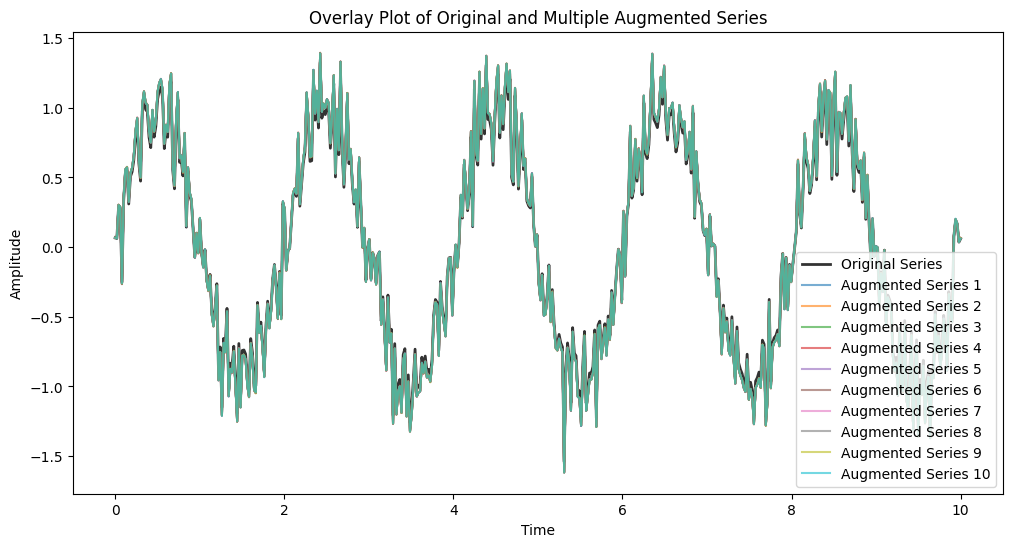


Frequency Spectrum Comparison with All Augmented Series:


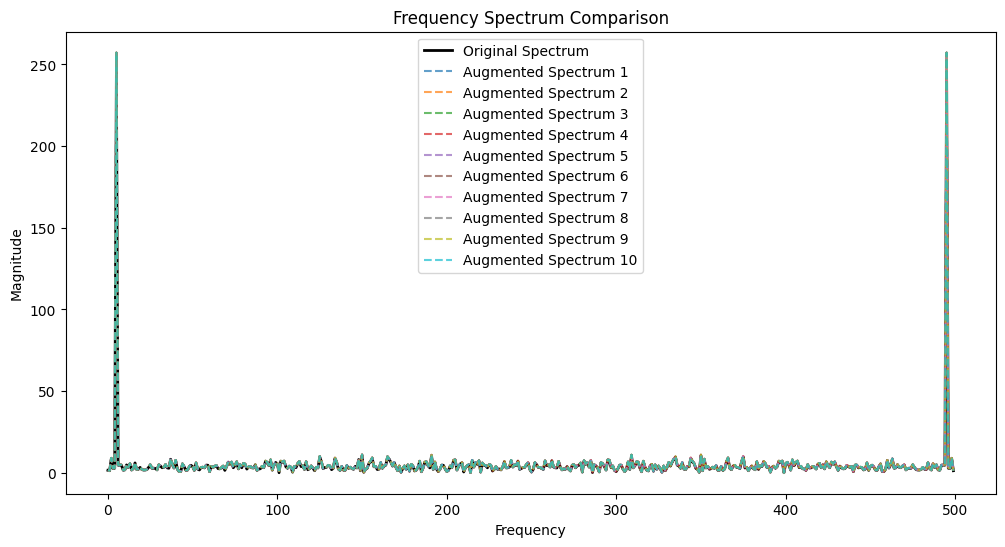


Correlation Plot with All Augmented Series:


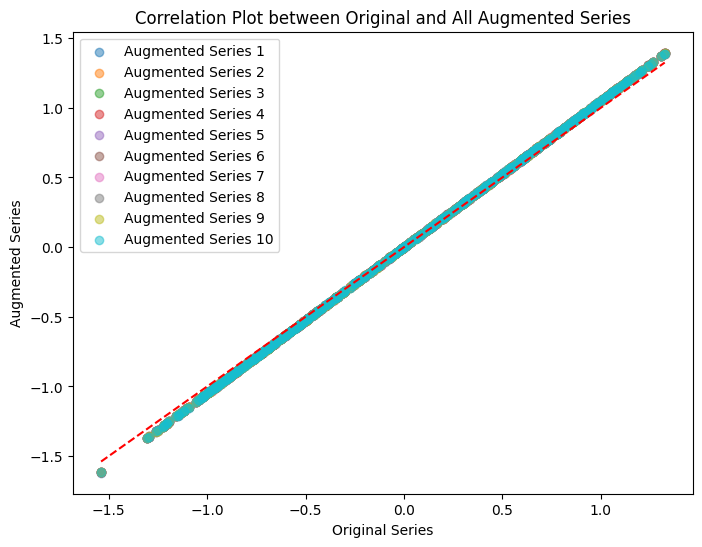


Residual Plot with All Augmented Series:


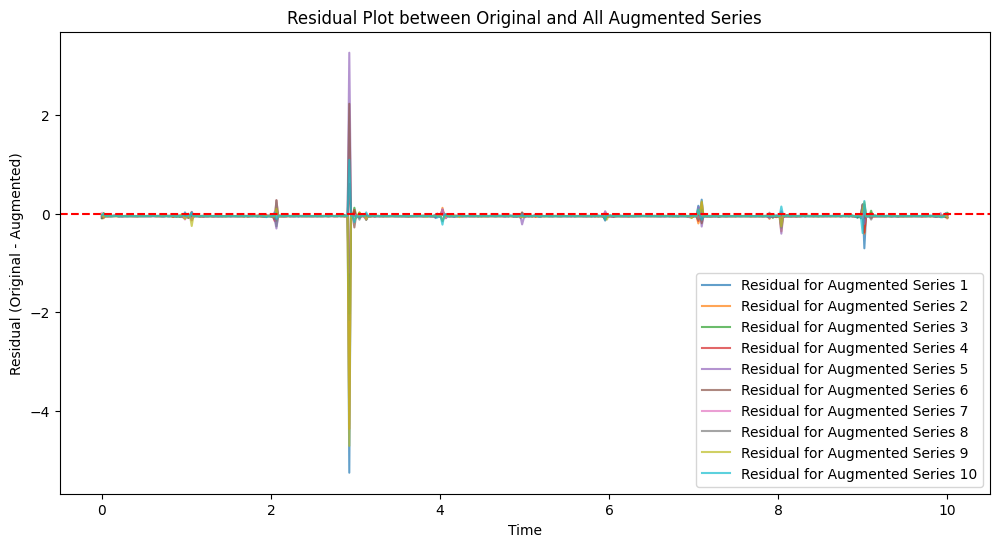

Original Mean: 0.003143412093512538
Augmented Mean: 0.0031434120935125557
Original Variance: 0.5181153690203111
Augmented Variance: 0.5712309694685951


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

""" set a random generator to have the same output each time, comment
    to generate a new set each time
"""
#np.random.seed(0)

""" fairly complicated signal - ours is more complicated... """
time = np.linspace(0, 10, 500)
original_series = np.sin(2 * np.pi * 0.5 * time) + 0.2 * np.random.normal(size=time.shape)

""" this is the engine for augmentation, change the noise and scale """
def fourier_augment(time_series, noise_factor=0.1, scale_factor=1.2):
    freq_domain = np.fft.fft(time_series)
    augmented_freq_domain = freq_domain * scale_factor
    noise = np.random.normal(size=freq_domain.shape) * noise_factor
    augmented_freq_domain = augmented_freq_domain + noise
    augmented_time_series = np.fft.ifft(augmented_freq_domain).real
    return augmented_time_series

def fourier_augment_dc(time_series, noise_factor=0.1, scale_factor=1.2):
    """
    another function preserving DC component of the signal

    Parameters:
    - time_series: The input time series data (1D array).
    - noise_factor: Magnitude of random noise added to the frequency components.
    - scale_factor: Multiplicative factor for scaling the frequency components.
    """
    # Perform Fourier Transform to convert to frequency domain
    freq_domain = np.fft.fft(time_series)

    # Preserve the DC component
    dc_component = freq_domain[0]

    # Apply scaling and noise to non-DC components
    freq_domain *= scale_factor
    freq_domain += np.random.normal(size=freq_domain.shape) * noise_factor

    # Restore the DC component
    freq_domain[0] = dc_component

    # Perform inverse Fourier Transform to convert back to time domain
    augmented_time_series = np.fft.ifft(freq_domain).real
    return augmented_time_series


""" multiple augmented series """
augmented_series_list = [fourier_augment_dc(original_series, noise_factor=0.05, scale_factor=1.05) for _ in range(10)]

""" simple compare - statistical based """
def statistical_comparison(original, augmented_list):
    for i, augmented in enumerate(augmented_list, 1):
        original_mean = np.mean(original)
        augmented_mean = np.mean(augmented)
        original_variance = np.var(original)
        augmented_variance = np.var(augmented)
        print(f"Augmented Series {i}:")
        print(f"Original Mean: {original_mean}, Augmented Mean: {augmented_mean}")
        print(f"Original Variance: {original_variance}, Augmented Variance: {augmented_variance}")
        print()

""" augmented vs. true - superposition """
def plot_overlay_multiple(original, augmented_list, time):
    plt.figure(figsize=(12, 6))
    plt.plot(time, original, label="Original Series", color="black", linewidth=2, alpha=0.8)
    for i, augmented in enumerate(augmented_list, 1):
        plt.plot(time, augmented, label=f"Augmented Series {i}", alpha=0.6)
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title("Overlay Plot of Original and Multiple Augmented Series")
    plt.show()

""" compare the augmented and original frequencies """
def frequency_spectrum_comparison_multiple(original, augmented_list):
    original_freq_spectrum = np.abs(np.fft.fft(original))
    plt.figure(figsize=(12, 6))
    plt.plot(original_freq_spectrum, label="Original Spectrum", color="black", linewidth=2)
    for i, augmented in enumerate(augmented_list, 1):
        augmented_freq_spectrum = np.abs(np.fft.fft(augmented))
        plt.plot(augmented_freq_spectrum, label=f"Augmented Spectrum {i}", linestyle="--", alpha=0.7)
    plt.legend()
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.title("Frequency Spectrum Comparison")
    plt.show()

""" simple correlation plot """
def correlation_plot_multiple(original, augmented_list):
    plt.figure(figsize=(8, 6))
    for i, augmented in enumerate(augmented_list, 1):
        plt.scatter(original, augmented, alpha=0.5, label=f"Augmented Series {i}")
    plt.xlabel("Original Series")
    plt.ylabel("Augmented Series")
    plt.title("Correlation Plot between Original and All Augmented Series")
    plt.plot([min(original), max(original)], [min(original), max(original)], 'r--')  # 1:1 line
    plt.legend()
    plt.show()

""" residual plot - select the best augmented series """
def residual_plot_multiple(original, augmented_list, time):
    plt.figure(figsize=(12, 6))
    for i, augmented in enumerate(augmented_list, 1):
        residuals = (original - augmented)/(original + 0.0000001)
        plt.plot(time, residuals, label=f"Residual for Augmented Series {i}", alpha=0.7)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Time")
    plt.ylabel("Residual (Original - Augmented)")
    plt.title("Residual Plot between Original and All Augmented Series")
    plt.legend()
    plt.show()

""" run """
print("Statistical Comparison:")
statistical_comparison(original_series, augmented_series_list)

print("\nOverlay Plot with Multiple Augmented Series:")
plot_overlay_multiple(original_series, augmented_series_list, time)

print("\nFrequency Spectrum Comparison with All Augmented Series:")
frequency_spectrum_comparison_multiple(original_series, augmented_series_list)

print("\nCorrelation Plot with All Augmented Series:")
correlation_plot_multiple(original_series, augmented_series_list)

print("\nResidual Plot with All Augmented Series:")
residual_plot_multiple(original_series, augmented_series_list, time)

print("Original Mean:", np.mean(original_series))
print("Augmented Mean:", np.mean(augmented_series_list))
print("Original Variance:", np.var(original_series))
print("Augmented Variance:", np.var(augmented_series_list))